In [2]:
import numpy as np
import nibabel as nib
import nilearn
from nilearn import plotting
import os

cn_project_t1_noise2

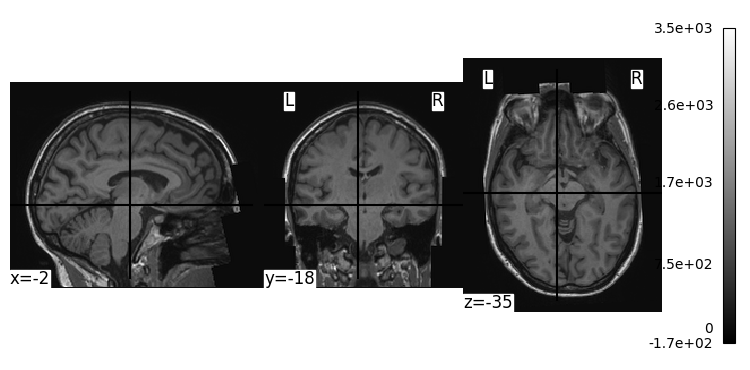

In [3]:
t1clean = '/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/dataset/cn_project_t1_noise2/1000012/T1_clean.nii.gz'
plotting.plot_img(t1clean)

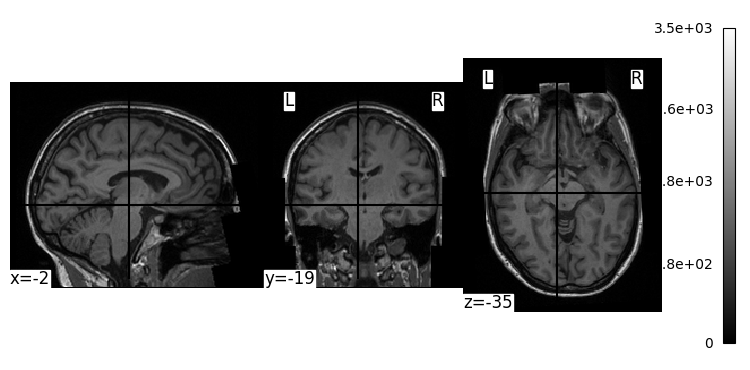

In [4]:
t1noisy = '/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/dataset/cn_project_t1_noise2/1000012/T1_noisy.nii.gz'
plotting.plot_img(t1noisy)

cn_project_t1t2

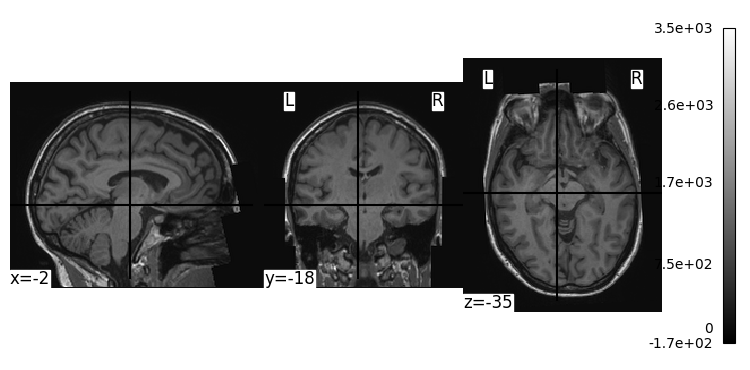

In [5]:
t1 = '/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/dataset/cn_project_t1t2/1000012/T1.nii.gz'
plotting.plot_img(t1)

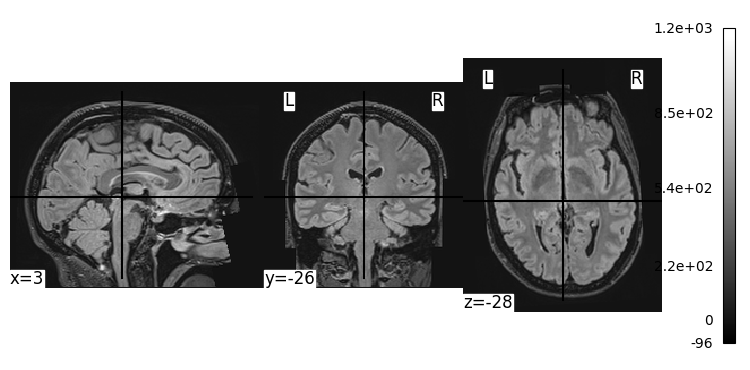

In [6]:
t2 = '/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/dataset/cn_project_t1t2/1000012/T2_FLAIR.nii.gz'
plotting.plot_img(t2)

test

In [7]:
from pathlib import Path

import nibabel as nib
import pandas as pd

PROJECT_ROOT = Path("/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final")
DATA_ROOT = PROJECT_ROOT / "dataset/cn_project_t1t2"
SPLIT_CSV = PROJECT_ROOT / "output/3dunet/smooth/t1tot2/split.csv"

split_df = pd.read_csv(SPLIT_CSV, dtype={"caseid": str})
test_caseids = split_df.loc[split_df["split"] == "test", "caseid"].tolist()

rows = []
for caseid in test_caseids:
    t1_path = DATA_ROOT / caseid / "T1.nii.gz"
    t2_path = DATA_ROOT / caseid / "T2_FLAIR.nii.gz"
    t1_shape = nib.load(str(t1_path)).shape
    t2_shape = nib.load(str(t2_path)).shape
    rows.append({
        "caseid": caseid,
        "T1_shape": t1_shape,
        "T2_FLAIR_shape": t2_shape,
        "depth": t1_shape[2],
        "same_shape": t1_shape == t2_shape,
    })

shape_df = pd.DataFrame(rows)
print(f"test cases: {len(shape_df)}")
display(shape_df)
display(shape_df["depth"].describe())



test cases: 60


,caseid,T1_shape,T2_FLAIR_shape,depth,same_shape
0,1022128,"(181, 218, 223)","(181, 218, 223)",223,True
1,1051284,"(167, 231, 192)","(167, 231, 192)",192,True
2,1062941,"(188, 245, 189)","(188, 245, 189)",189,True
3,1077912,"(178, 240, 193)","(178, 240, 193)",193,True
4,1076850,"(179, 224, 197)","(179, 224, 197)",197,True
5,1013344,"(168, 227, 213)","(168, 227, 213)",213,True
6,1081139,"(178, 226, 192)","(178, 226, 192)",192,True
7,1011088,"(170, 221, 176)","(170, 221, 176)",176,True
8,1041095,"(175, 231, 212)","(175, 231, 212)",212,True
9,1031157,"(167, 225, 194)","(167, 225, 194)",194,True


count     60.000000
mean     201.400000
std       13.239899
min      167.000000
25%      193.000000
50%      204.000000
75%      211.000000
max      239.000000
Name: depth, dtype: float64

Eval predictions 展示


In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final")
DATA_ROOT = PROJECT_ROOT / "dataset/cn_project_t1t2"
sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_nifti_dhw


def choose_slice(volume):
    scores = (np.abs(volume) > 0).sum(axis=(1, 2))
    return int(scores.argmax()) if scores.max() > 0 else volume.shape[0] // 2


def display_eval_predictions(output_dir, title, n=3, caseids=None):
    output_dir = PROJECT_ROOT / output_dir
    eval_df = pd.read_csv(output_dir / "eval.csv", dtype={"caseid": str})
    if caseids is not None:
        eval_df = eval_df[eval_df["caseid"].isin([str(x) for x in caseids])]
    rows = eval_df.head(n).to_dict("records")
    print(f"{title}: {output_dir / 'eval.csv'}")
    print(f"cases={[row['caseid'] for row in rows]}")

    for row in rows:
        caseid = str(row["caseid"])
        case_dir = DATA_ROOT / caseid
        source_name = row["source"]
        target_name = row["target"]
        pred_path = output_dir / "predictions" / f"{caseid}_{target_name}.nii.gz"
        if not pred_path.exists():
            pred_path = PROJECT_ROOT / row["prediction_path"]

        source, _ = load_nifti_dhw(case_dir / f"{source_name}.nii.gz")
        target, _ = load_nifti_dhw(case_dir / f"{target_name}.nii.gz")
        pred, _ = load_nifti_dhw(pred_path)
        z = choose_slice(target)

        panels = [
            np.rot90(source[z]),
            np.rot90(pred[z]),
            np.rot90(target[z]),
            np.rot90(np.abs(pred[z] - target[z])),
        ]
        src_vmin, src_vmax = np.percentile(panels[0], [1, 99])
        tgt_vmin, tgt_vmax = np.percentile(np.concatenate([panels[1].ravel(), panels[2].ravel()]), [1, 99])
        err_vmax = np.percentile(panels[3], 99)

        fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
        titles = [
            f"{caseid} {source_name} input\nz={z}",
            f"Pred {target_name}\nSSIM={row['ssim']:.3f}",
            f"True {target_name}",
            f"Absolute error\nMAE={row['mae']:.2f}",
        ]
        cmaps = ["gray", "gray", "gray", "magma"]
        ranges = [(src_vmin, src_vmax), (tgt_vmin, tgt_vmax), (tgt_vmin, tgt_vmax), (0, err_vmax)]
        for ax, img, panel_title, cmap, (vmin, vmax) in zip(axes, panels, titles, cmaps, ranges):
            im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(panel_title)
            ax.axis("off")
        fig.suptitle(title)
        fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
        fig.tight_layout()
        plt.show()


3D U-Net: T1 -> T2_FLAIR


3D U-Net: T1 -> T2_FLAIR: /mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/output/3dunet/smooth/t1tot2/eval.csv
cases=['1000542', '1002722', '1002807']


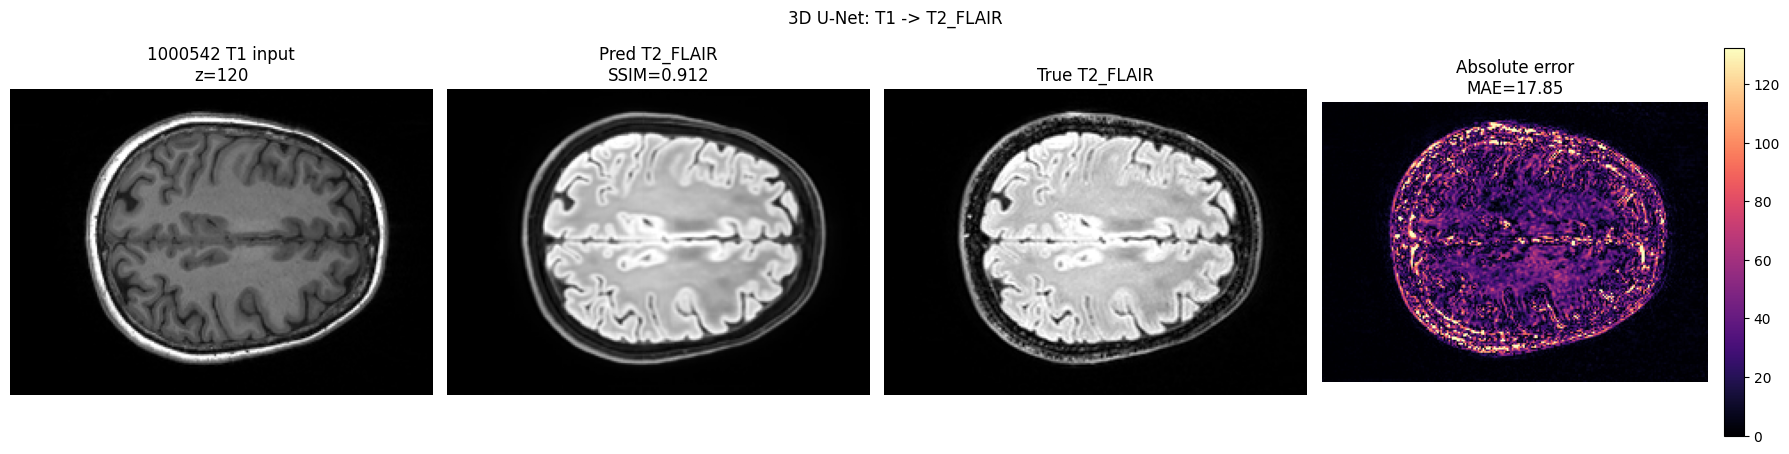

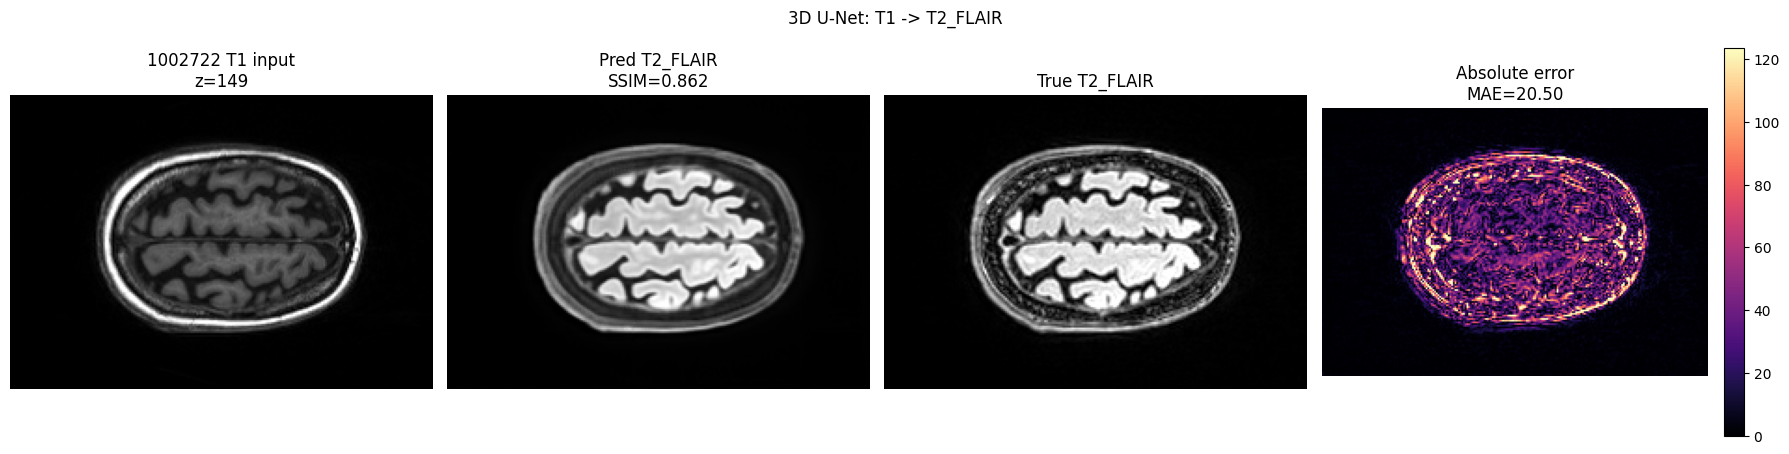

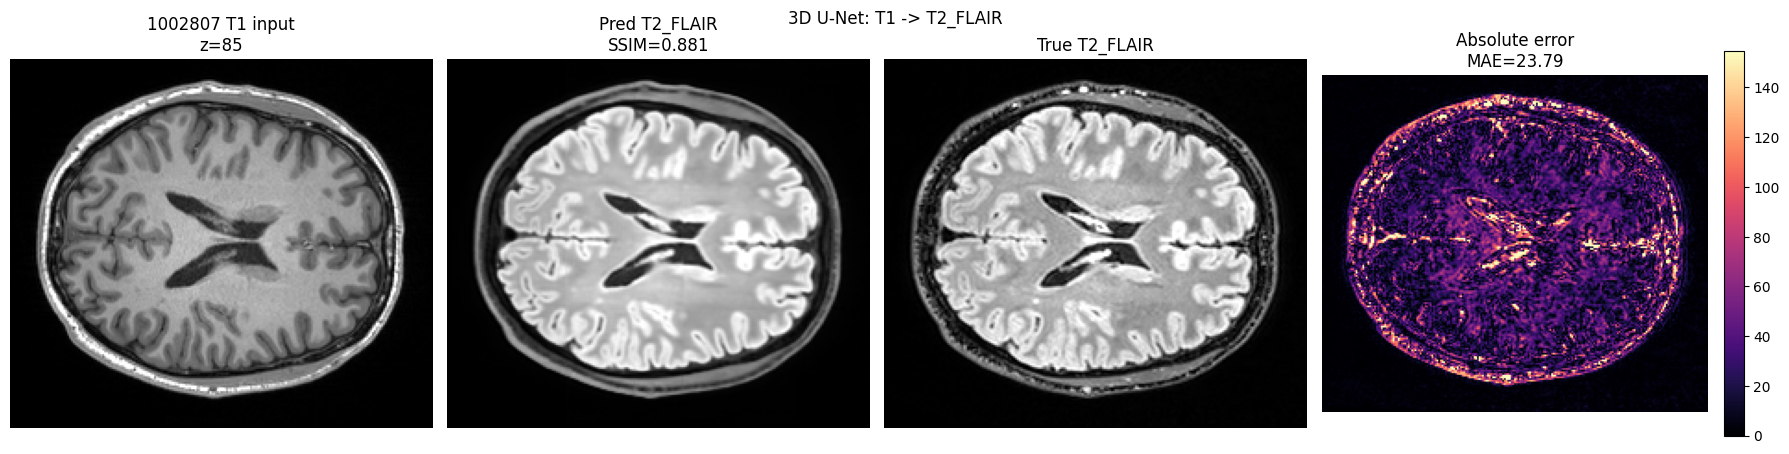

In [14]:
display_eval_predictions("output/3dunet/smooth/t1tot2", "3D U-Net: T1 -> T2_FLAIR")

2.5D U-Net: T1 -> T2_FLAIR

2D / 2.5D U-Net: T1 -> T2_FLAIR: /mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/output/2dunet/t1tot2/eval.csv
cases=['1000542', '1002722', '1002807']


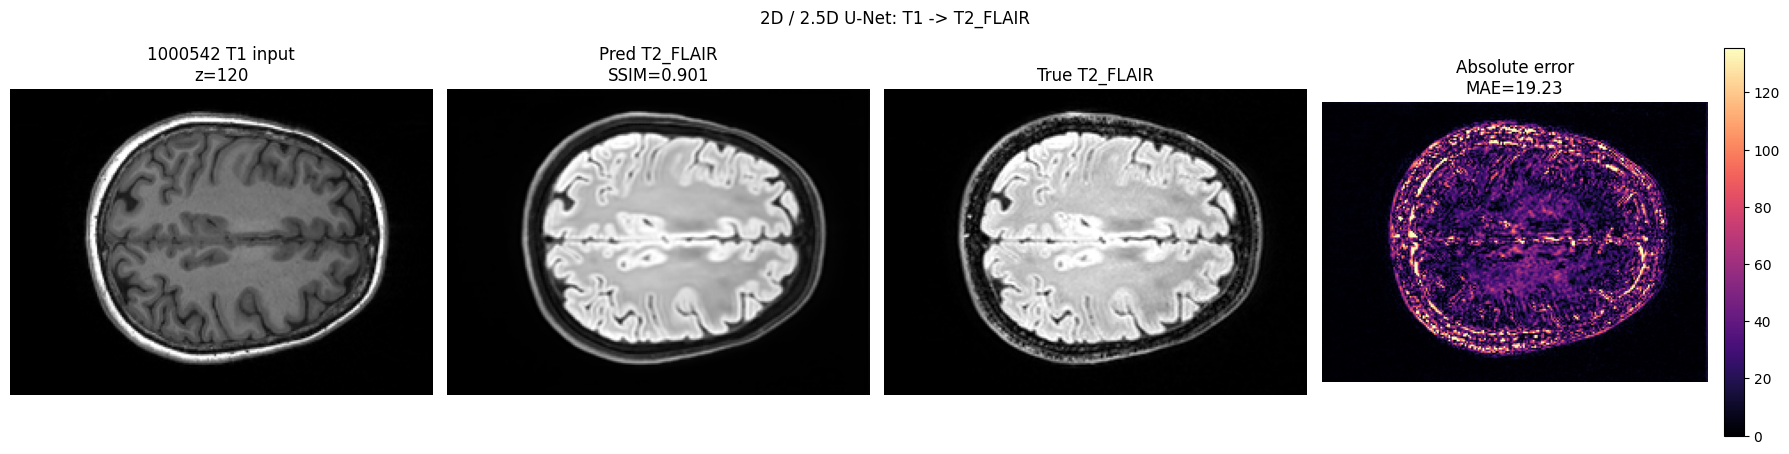

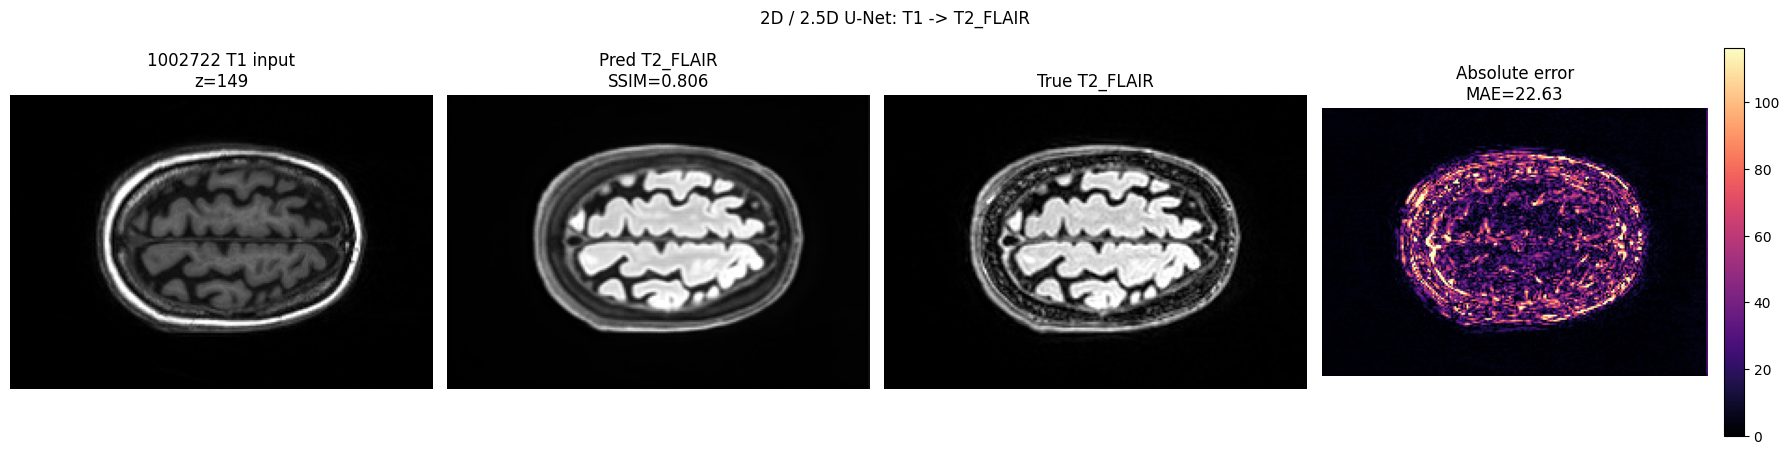

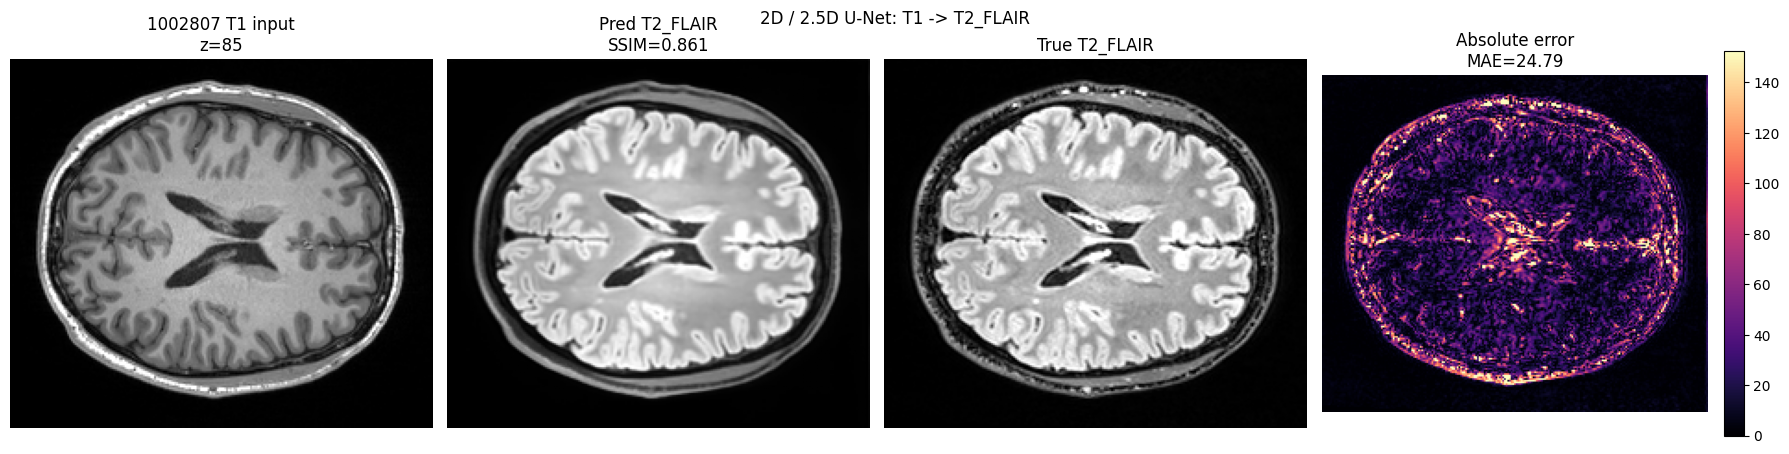

In [15]:
display_eval_predictions("output/2dunet/t1tot2", "2D / 2.5D U-Net: T1 -> T2_FLAIR")

3D U-Net: T2_FLAIR -> T1


3D U-Net: T2_FLAIR -> T1: /mnt/data/haoyang/workspace/hw/FDU-computational-neuroscience-26spring/final/output/3dunet/smooth/t2tot1/eval.csv
cases=['1000542', '1002722', '1002807']


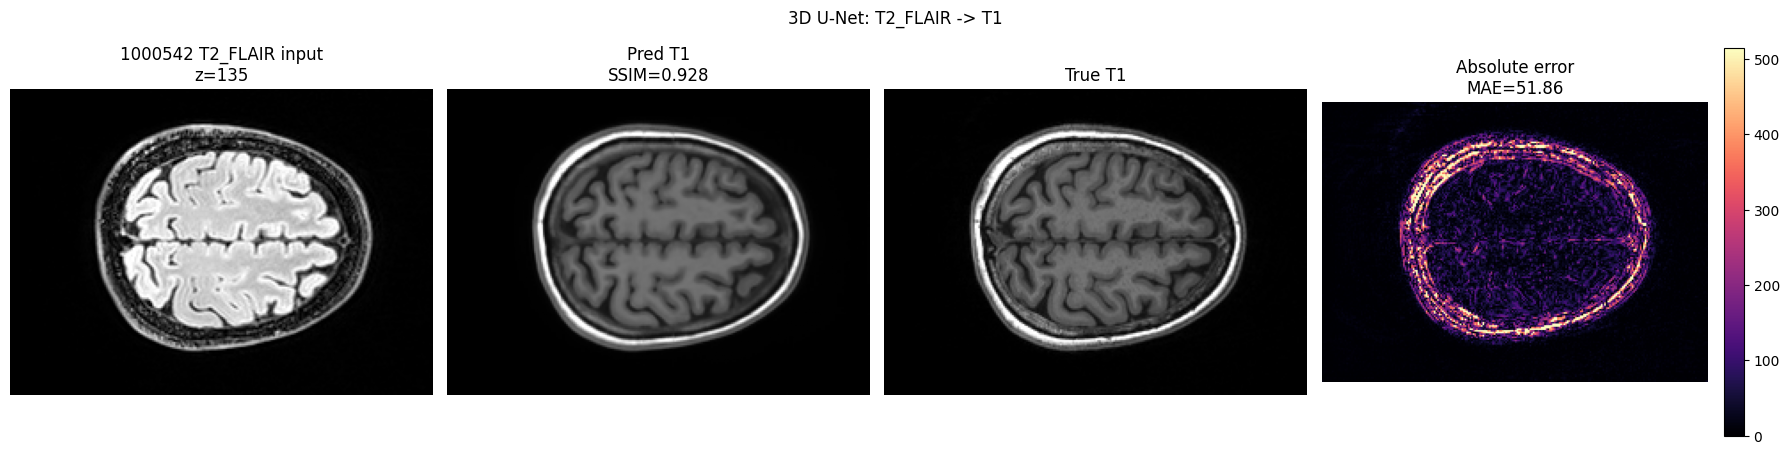

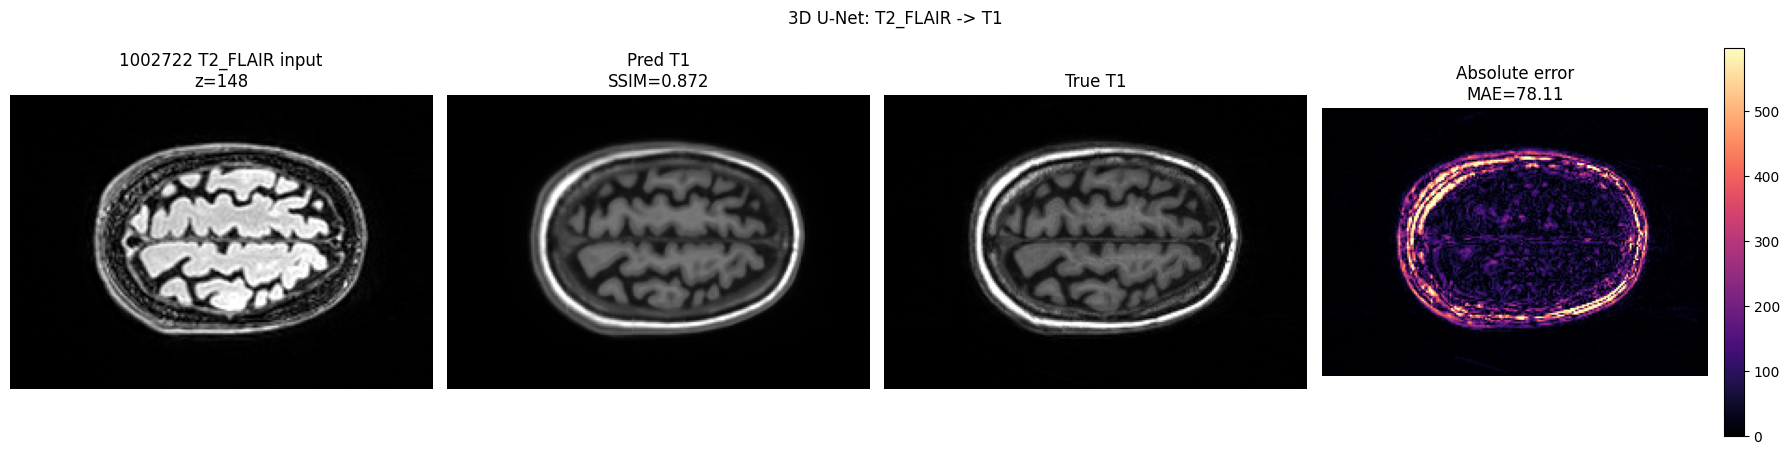

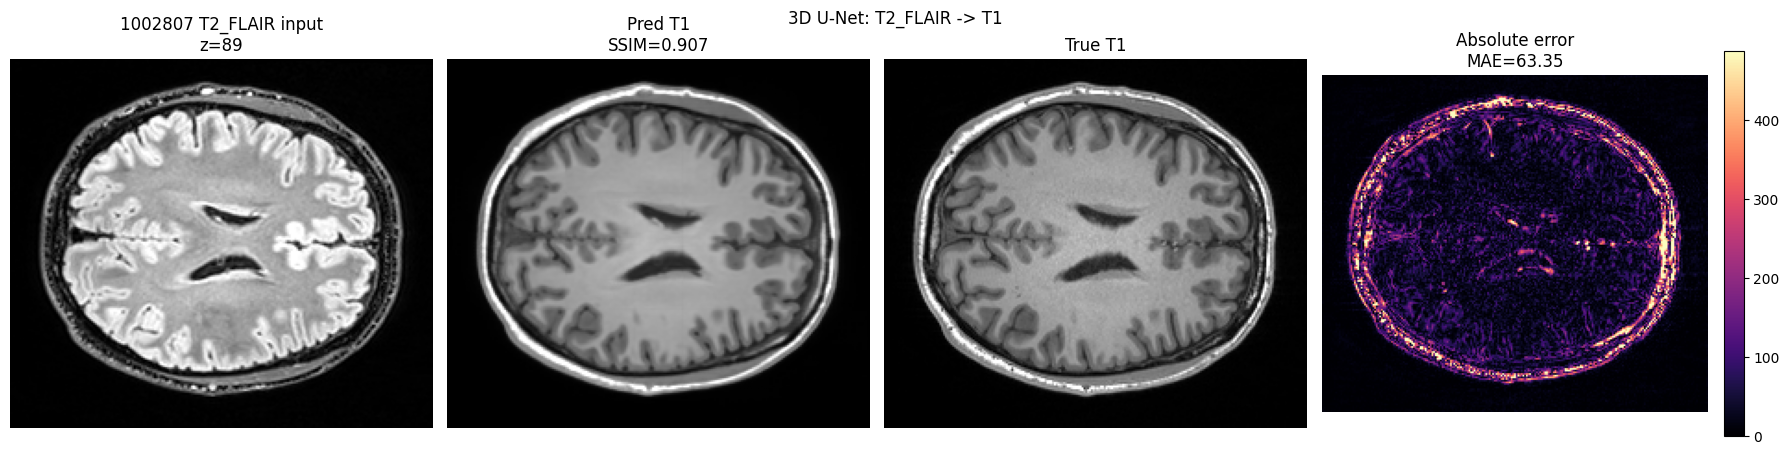

In [16]:
display_eval_predictions("output/3dunet/smooth/t2tot1", "3D U-Net: T2_FLAIR -> T1")